**ФИО:** Комиссаров Антон Сергеевич

**Группа:** М8О-209СВ-24

# 1 | Разведочный анализ данных (EDA)

## Предварительный анализ временного ряда:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import pywt
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson


df = pd.read_csv("retail_sales_mock_data.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


Описание признаков:

In [2]:
df.describe()

,SalesAmount,Promotion,HolidayMonth
count,48.000000,48.000000,48.000000
mean,11768.541667,0.125000,0.083333
std,2257.544863,0.334219,0.279310
min,7783.000000,0.000000,0.000000
25%,10219.750000,0.000000,0.000000
50%,11851.000000,0.000000,0.000000
75%,13014.000000,0.000000,0.000000
max,17996.000000,1.000000,1.000000


Количество пропусков:

In [3]:
display(df.isna().sum())

,0
SalesAmount,0
Promotion,0
HolidayMonth,0


In [4]:
print(f"Период наблюдений: {df.index.min().date()} — {df.index.max().date()}")
print(f"Количество записей: {len(df)}")

Период наблюдений: 2020-01-01 — 2023-12-01
Количество записей: 48


**Выводы:**
* Набор данных состоит из 48 записей (ежемесячные наблюдения за 4 года - c 2020 по 2023 год).
* Пропуски в данных отсутствуют.
* Целевая переменная - *SalesAmount* (объём продаж).
* Признаки: *Promotion* (наличие промо-акции), *HolidayMonth* (праздничный месяц).

Проверим ряд на стационарность:

In [5]:
def adf_test(x: pd.Series, title: str):
    stat, pvalue, *_ = adfuller(x.dropna(), autolag="AIC")
    print(f"{title}: ADF-статистика = {stat:.3f}, p-value = {pvalue:.4f}")
    print(f"\tВывод: {'ряд стационарен (p < 0.05)' if pvalue < 0.05 else 'ряд НЕстационарен (p >= 0.05)'}")


print("Тест Дики–Фуллера для исходного ряда:")
adf_test(df['SalesAmount'], "Исходный ряд")
print("\nТест Дики–Фуллера для разностей первого порядка:")
adf_test(df['SalesAmount'].diff(), "Разности первого порядка")

Тест Дики–Фуллера для исходного ряда:
Исходный ряд: ADF-статистика = -4.514, p-value = 0.0002
	Вывод: ряд стационарен (p < 0.05)

Тест Дики–Фуллера для разностей первого порядка:
Разности первого порядка: ADF-статистика = -5.630, p-value = 0.0000
	Вывод: ряд стационарен (p < 0.05)


## Визуализация:

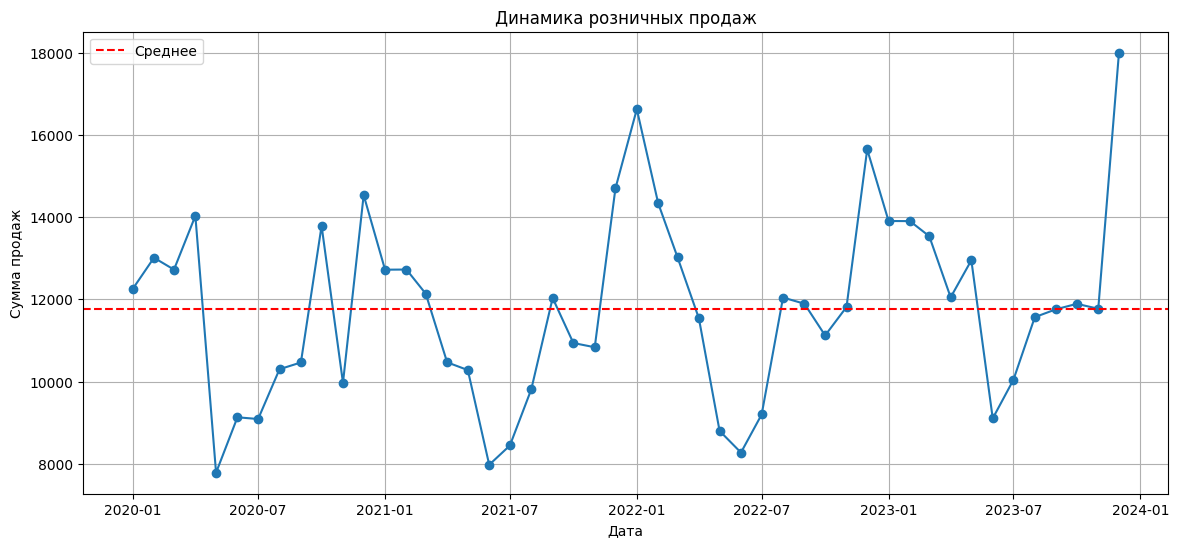

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['SalesAmount'], marker='o')
plt.title('Динамика розничных продаж')
plt.axhline(df["SalesAmount"].astype(float).mean(), color="red", linestyle="--", label="Среднее")
plt.xlabel('Дата')
plt.ylabel('Сумма продаж')
plt.grid(True)
plt.legend()
plt.show()

**Вывод:** На графике видно, что каждый год на новогодних праздниках происходит всплеск продаж, а в середине лета - сильный спад. Прослеживается явная периодничность, а также общий слабо восходящий тренд

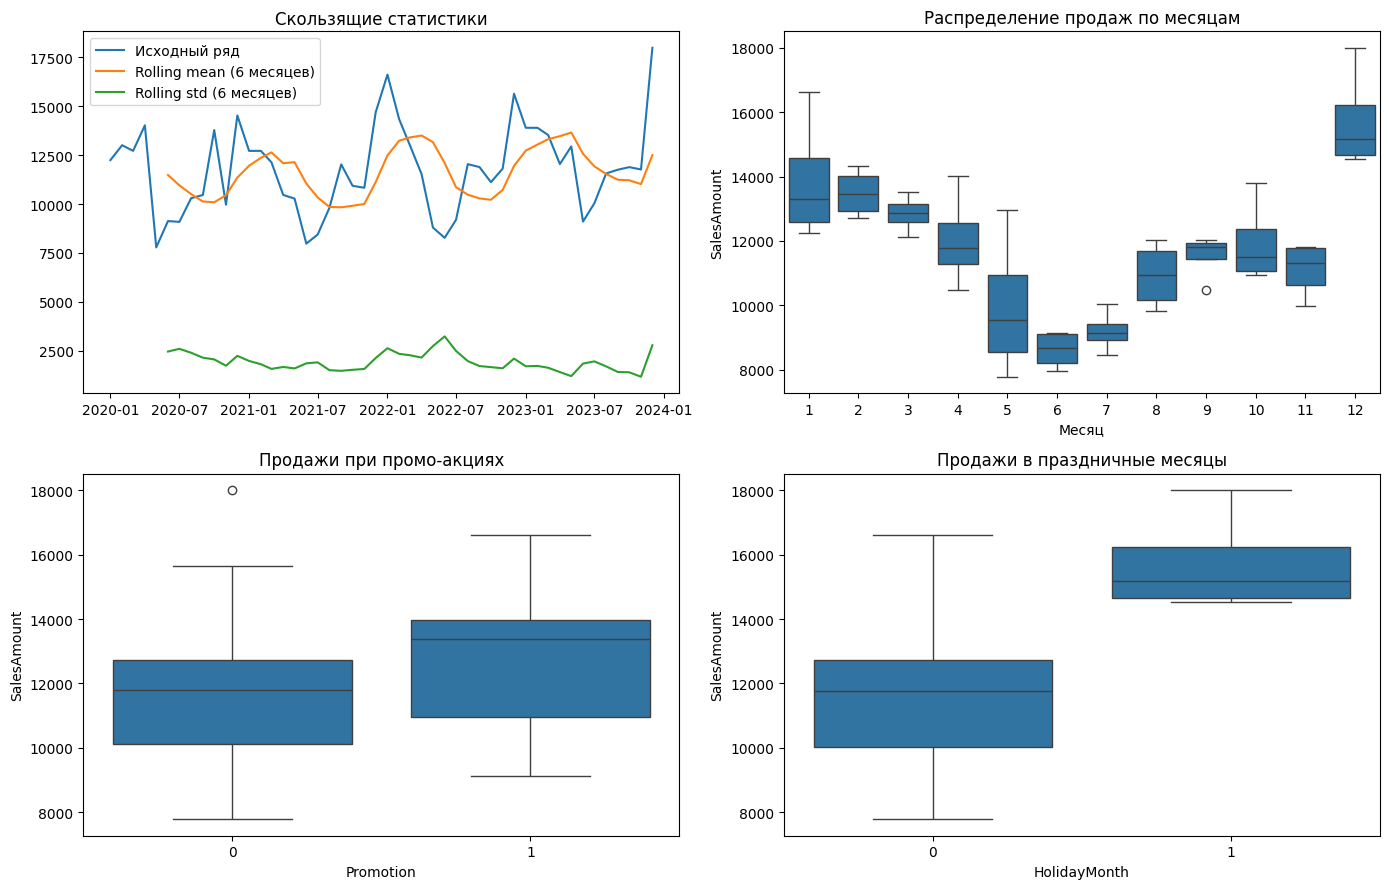

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

roll_mean = df["SalesAmount"].rolling(window=6).mean()
roll_std = df["SalesAmount"].rolling(window=6).std()
axes[0, 0].plot(df.index, df["SalesAmount"], label="Исходный ряд")
axes[0, 0].plot(df.index, roll_mean, label="Rolling mean (6 месяцев)", color="tab:orange",)
axes[0, 0].plot(df.index, roll_std, label="Rolling std (6 месяцев)", color="tab:green")
axes[0, 0].set_title("Скользящие статистики")
axes[0, 0].legend()

tmp = df.copy()
tmp["month"] = tmp.index.month
sns.boxplot(data=tmp, x="month", y="SalesAmount", ax=axes[0, 1])
axes[0, 1].set_title("Распределение продаж по месяцам")
axes[0, 1].set_xlabel("Месяц")


sns.boxplot(x='Promotion', y='SalesAmount', data=df, ax=axes[1,0])
axes[1, 0].set_title("Продажи при промо-акциях")

sns.boxplot(x='HolidayMonth', y='SalesAmount', data=df, ax=axes[1,1])
axes[1, 1].set_title("Продажи в праздничные месяцы")

plt.tight_layout()
plt.show()

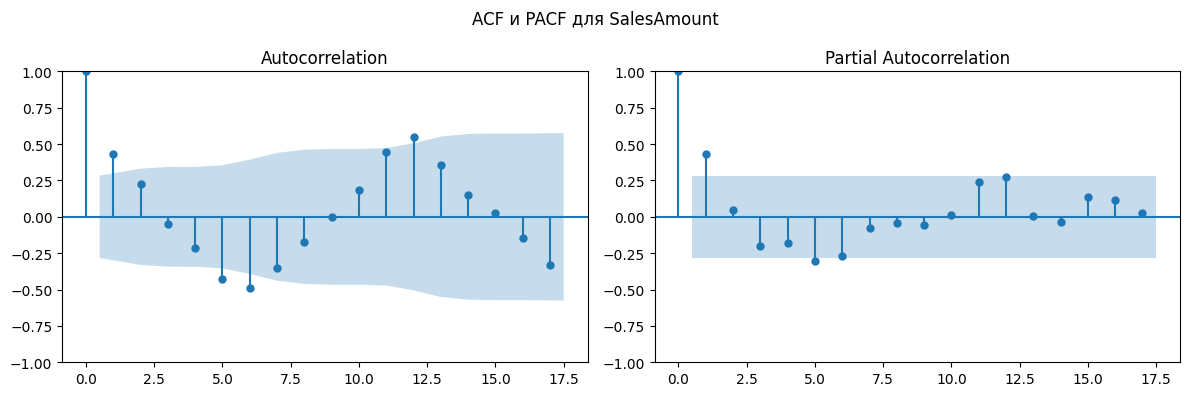

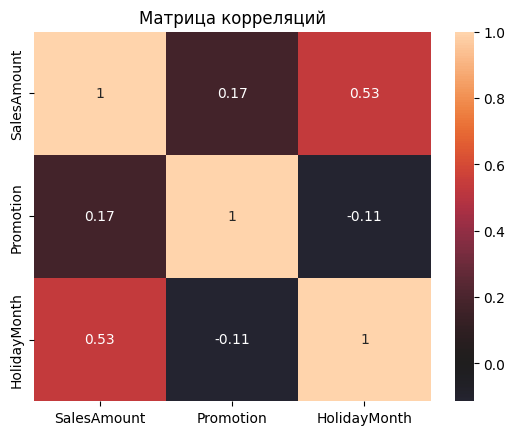

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['SalesAmount'], ax=axes[0])
plot_pacf(df['SalesAmount'], ax=axes[1])
plt.suptitle('ACF и PACF для SalesAmount')
plt.tight_layout()
plt.show()

corr = df.corr()
sns.heatmap(corr, annot=True, center=0)
plt.title('Матрица корреляций')
plt.show()

**Выводы:**
* Медленное затухание ACF означает нестационарность (нужно дифференцирование).
* Значимые лаги на 12 - годовая сезонность (период - 12 месяцев).
* Корреляция продаж с *HolidayMonth* - +0.53, что подтверждает сильное влияние праздников, а с *Promotion* - +0.17 - слабое влияние промо-акций.
* ACF показывает значимые лаги 1 и 12, что подтверждает нестационарность и годовую сезонность.

## Декомпозиция:

Построим классическую декомпозицию для периода в 12 месяцев (годовая сезонность):

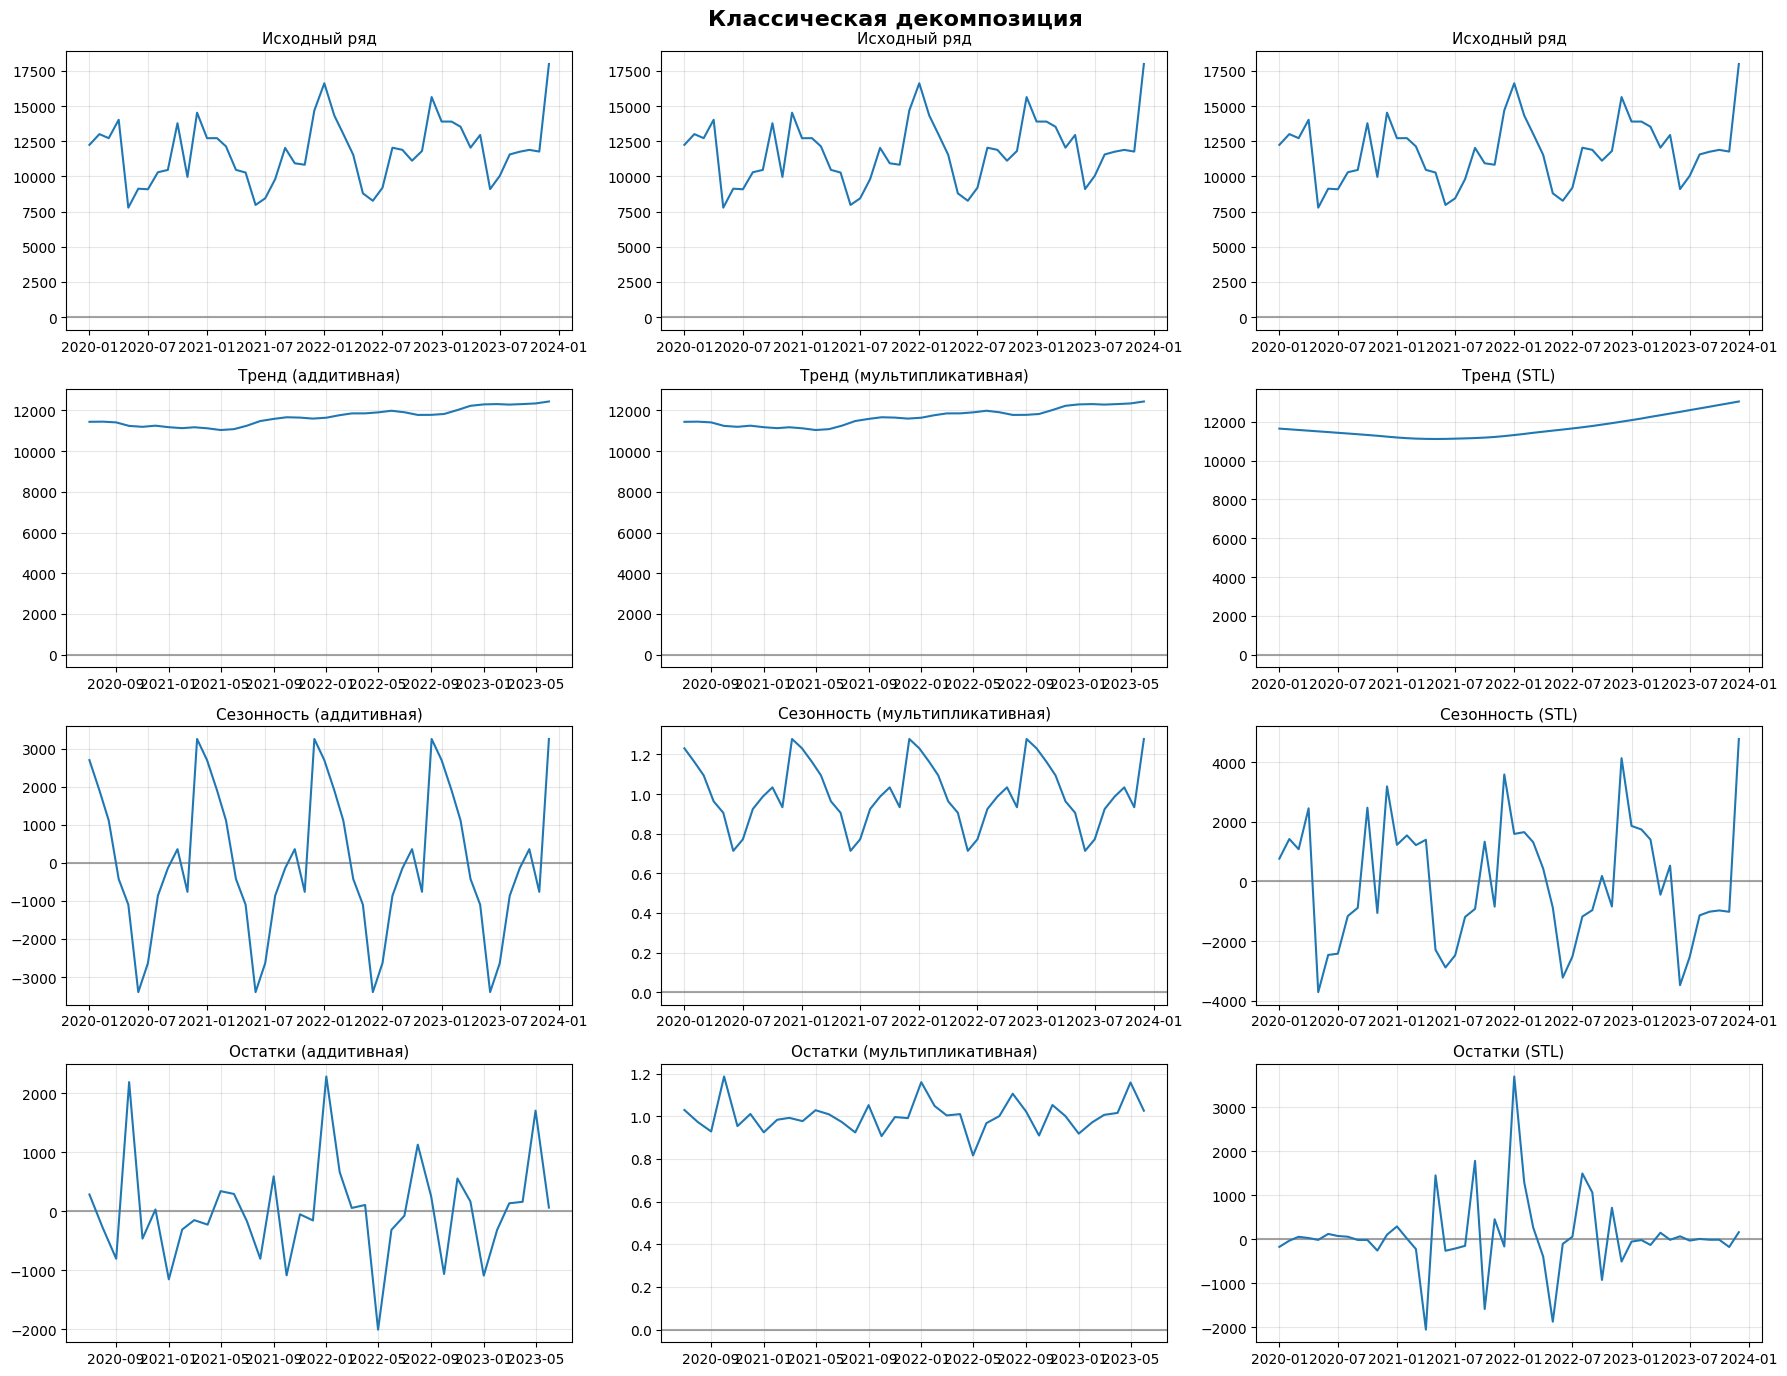

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Классическая декомпозиция', fontsize=16, fontweight='bold')
for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.7)

# Аддитивная
decomp_add = seasonal_decompose(df['SalesAmount'], model='additive', period=12)
axes[0, 0].plot(df.index, df['SalesAmount'])
axes[0, 0].set_title('Исходный ряд', fontsize=11)
axes[1, 0].plot(df.index, decomp_add.trend)
axes[1, 0].set_title('Тренд (аддитивная)', fontsize=11)
axes[2, 0].plot(df.index, decomp_add.seasonal)
axes[2, 0].set_title('Сезонность (аддитивная)', fontsize=11)
axes[3, 0].plot(df.index, decomp_add.resid)
axes[3, 0].set_title('Остатки (аддитивная)', fontsize=11)

# Мультипликативная
decomp_mult = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)
axes[0, 1].plot(df.index, df['SalesAmount'])
axes[0, 1].set_title('Исходный ряд', fontsize=11)
axes[1, 1].plot(df.index, decomp_mult.trend)
axes[1, 1].set_title('Тренд (мультипликативная)', fontsize=11)
axes[2, 1].plot(df.index, decomp_mult.seasonal)
axes[2, 1].set_title('Сезонность (мультипликативная)', fontsize=11)
axes[3, 1].plot(df.index, decomp_mult.resid)
axes[3, 1].set_title('Остатки (мультипликативная)', fontsize=11)

# STL
decomp_stl = STL(df['SalesAmount'], period=12, robust=True).fit()
axes[0, 2].plot(df.index, df['SalesAmount'])
axes[0, 2].set_title('Исходный ряд', fontsize=11)
axes[1, 2].plot(df.index, decomp_stl.trend)
axes[1, 2].set_title('Тренд (STL)', fontsize=11)
axes[2, 2].plot(df.index, decomp_stl.seasonal)
axes[2, 2].set_title('Сезонность (STL)', fontsize=11)
axes[3, 2].plot(df.index, decomp_stl.resid)
axes[3, 2].set_title('Остатки (STL)', fontsize=11)

plt.tight_layout()
plt.show()

**Вывод:** Методы подтверждают наличие устойчивой годовой сезонности. STL более устойчив к выбросам и может моделировать изменяющуюся сезонность, что позволяет наиболее наглядно отобразить тренд

Проведём спектральный анализ с применением быстрого преобразования Фурье
(FFT):

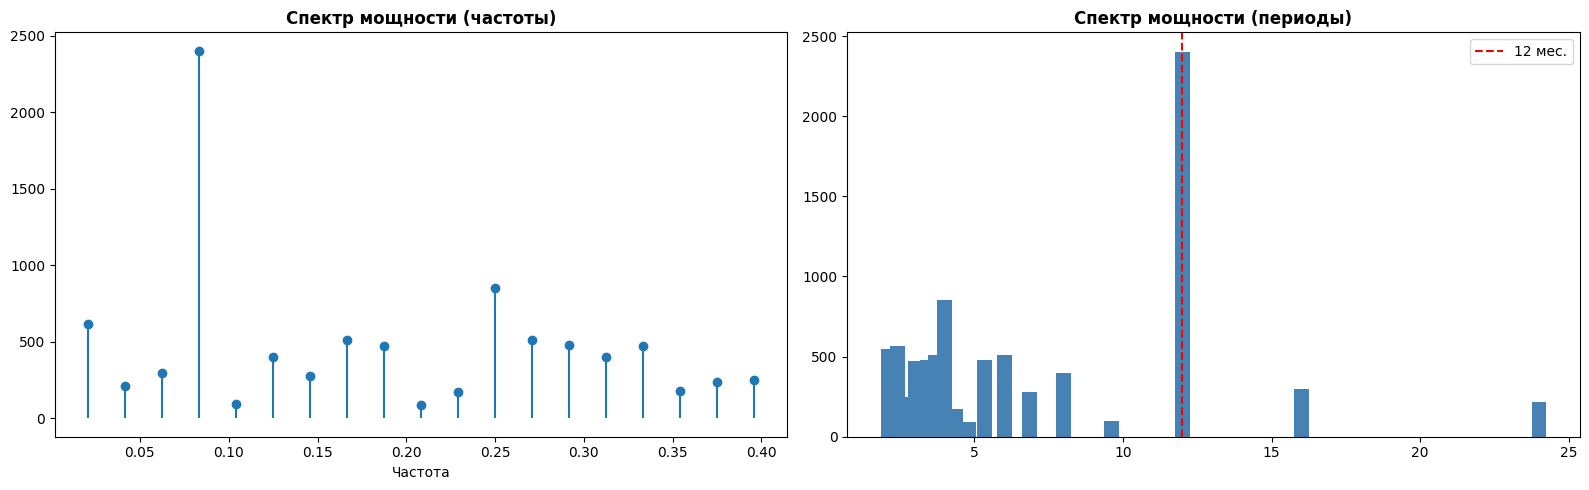

Доминирующие периоды:
  1. 12.0 мес., амплитуда: 2403.3
  2. 4.0 мес., амплитуда: 854.3
  3. 48.0 мес., амплитуда: 616.4
  4. 2.4 мес., амплитуда: 564.2
  5. 2.1 мес., амплитуда: 545.1


In [10]:
y = df["SalesAmount"] - df["SalesAmount"].mean()
n = len(y)

yf = fft(y)
xf = fftfreq(n, d=1)[:n//2]
power = 2.0/n * np.abs(yf[0:n//2])
periods = 1 / xf[1:]
power_periods = power[1:]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].stem(xf[1:20], power[1:20], basefmt=' ')
axes[0].set_title('Спектр мощности (частоты)', fontweight='bold')
axes[0].set_xlabel('Частота')

mask = periods <= 24
axes[1].bar(periods[mask], power_periods[mask], width=0.5, color='steelblue')
axes[1].axvline(x=12, color='red', linestyle='--', label='12 мес.')
axes[1].set_title('Спектр мощности (периоды)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

top_indices = np.argsort(power_periods)[-5:][::-1]
print("Доминирующие периоды:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i}. {periods[idx]:.1f} мес., амплитуда: {power_periods[idx]:.1f}")

**Вывод:** Спектральный анализ показывает ярко выраженный период в 12 месяцев, что совпадает с календарной годовой сезонностью

Проведём вейвлет-анализ нормированного ряда с вейвлетом Морле:

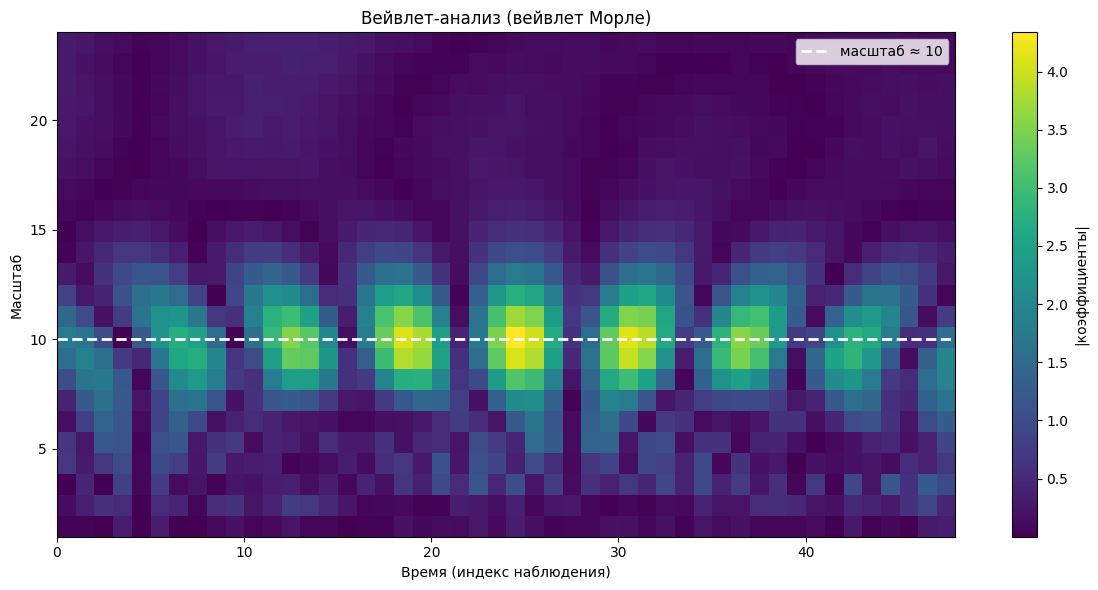

In [11]:
scales = np.arange(1, 25)
norm_sales = (df["SalesAmount"].values - df["SalesAmount"].mean()) / df["SalesAmount"].std()
coef, freqs_w = pywt.cwt(norm_sales, scales, "morl")

plt.figure(figsize=(12, 6))
extent = [0, len(df["SalesAmount"]), scales.min(), scales.max()]
plt.imshow(
    np.abs(coef),
    extent=extent,
    cmap="viridis",
    aspect="auto",
    origin="lower",
)
plt.colorbar(label="|коэффициенты|")
plt.axhline(10, color="white", linestyle="--", linewidth=2, label="масштаб ≈ 10")
plt.xlabel("Время (индекс наблюдения)")
plt.ylabel("Масштаб")
plt.title("Вейвлет-анализ (вейвлет Морле)")
plt.legend()
plt.tight_layout()
plt.show()

mean_power = np.mean(np.abs(coef) ** 2, axis=1)
dominant_scale = scales[np.argmax(mean_power)]

**Вывод:** Наблюдается устойчивое проявление цикличности с максимальной мощностью в области масштабов, которые соответствуют годовому периоду, что подтверждает наличие годовой сезонности

**Общие выводы по сравнению методов декомпозиции:**
- Аддитивная модель является простой и удобной для интерпретации, однако она предполагает неизменность сезонной компоненты во времени. Мультипликативная модель учитывает пропорциональное изменение сезонности относительно уровня ряда, но может применяться только к временным рядам с положительными значениями. STL-декомпозиция отличается большей устойчивостью к выбросам и локальным изменениям структуры ряда, хотя требует больших вычислительных затрат.
- Спектральный анализ на основе быстрого преобразования Фурье (FFT) позволяет выявить доминирующие периодические компоненты временного ряда, однако не отражает их динамику во времени. FFT подтвердил наличие годового цикла (период 12 месяцев), также видны всплески на частотах, соответствующих полугодию (6 мес.) и кварталу (3 мес.), что может указывать на внутригодовую сезонность. В отличие от FFT, вейвлет-анализ обеспечивает временную локализацию частотных характеристик, что делает его полезным для анализа нестационарных рядов, но приводит к более сложной интерпретации полученных результатов и возможной потере информации на границах ряда.
- Результаты всех рассмотренных методов указывают на наличие выраженной годовой сезонности с периодом в 12 месяцев. STL-декомпозиция демонстрирует наименьшую дисперсию остаточной компоненты, FFT точно выявляет доминирующую частоту, а вейвлет-анализ подтверждает устойчивость сезонной структуры на протяжении всего временного интервала. С учётом полученных результатов для дальнейшего моделирования наиболее целесообразно использовать STL-декомпозицию или аддитивную модель.

# 2 | Построение прогнозных моделей

Разделим данные на обучающую и тестовую выборки: последний год (12 месяцев) оставим для проверки качества прогноза

Train: 36 (2020-01-01 00:00:00 — 2022-12-01 00:00:00)
Test: 12 (2023-01-01 00:00:00 — 2023-12-01 00:00:00)


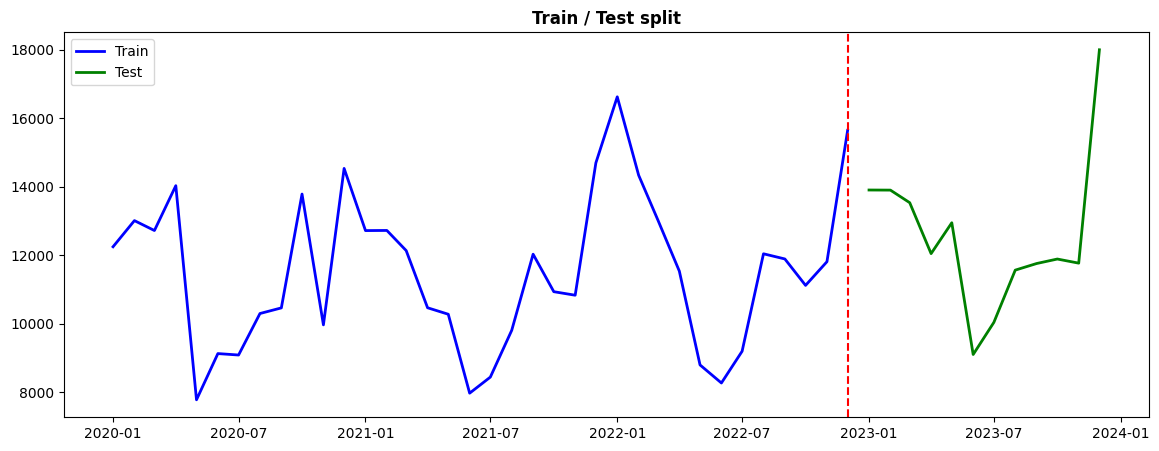

In [12]:
train_size = int(len(df) * 0.75)
train = df[:train_size]
test = df[train_size:]

print(f"Train: {len(train)} ({train.index.min()} — {train.index.max()})")
print(f"Test: {len(test)} ({test.index.min()} — {test.index.max()})")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train["SalesAmount"], 'b-', label='Train', linewidth=2)
ax.plot(test.index, test["SalesAmount"], 'g-', label='Test', linewidth=2)
ax.axvline(x=train.index[-1], color='red', linestyle='--')
ax.set_title('Train / Test split', fontweight='bold')
ax.legend()
plt.show()

## Модель ARIMA:

На основе EDA и теста Дики-Фуллера мы знаем, что ряд нестационарен (d>=1). Для выбора p и q можно использовать ACF/PACF дифференцированного ряд

Первая разность: ADF-статистика = -4.593, p-value = 0.0001
	Вывод: ряд стационарен (p < 0.05)


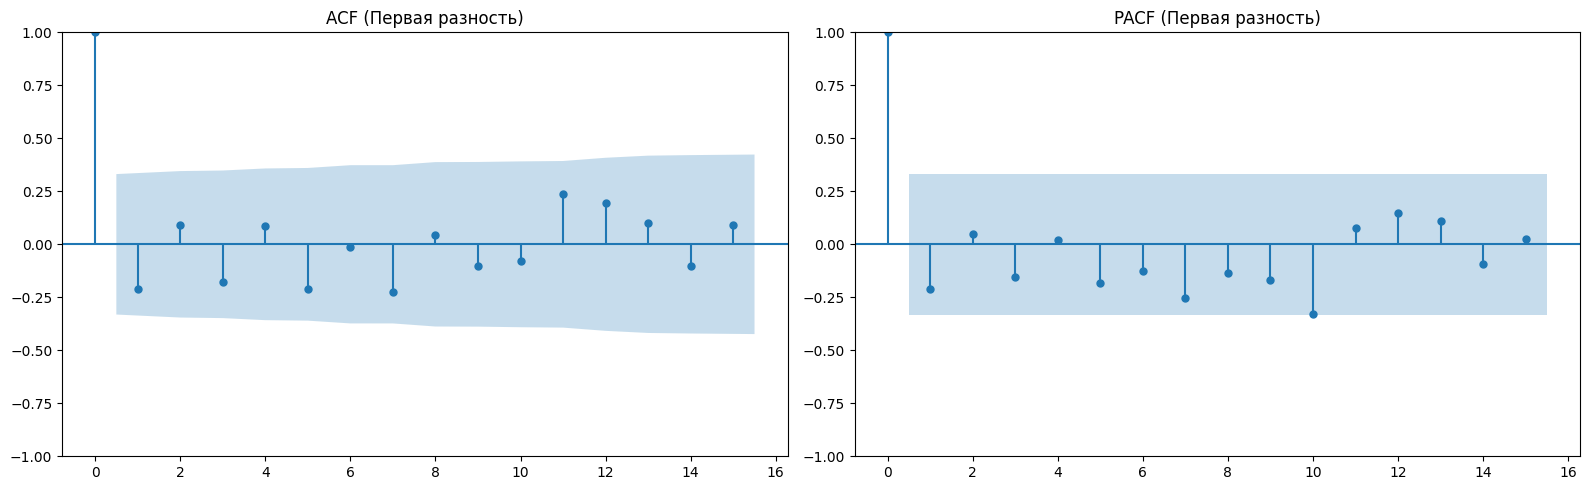

In [13]:
train_diff = train['SalesAmount'].diff().dropna()
adf_test(train_diff, 'Первая разность')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(train_diff, lags=15, ax=ax1)
ax1.set_title('ACF (Первая разность)')
plot_pacf(train_diff, lags=15, ax=ax2)
ax2.set_title('PACF (Первая разность)')
plt.tight_layout()
plt.show()

In [14]:
import warnings
warnings.filterwarnings('ignore')

p_values = list(range(2))
d_values = [1]  # ряд стал стационарным после 1-го дифференцирования
q_values = list(range(2))
best_aic, best_order = float('inf'), None

for p, d, q in product(p_values, d_values, q_values):
    try:
        model = ARIMA(train['SalesAmount'], order=(p, d, q)).fit()
        if model.aic < best_aic:
            best_aic, best_order = model.aic, (p, d, q)
    except:
        continue

print(f"Лучшая модель ARIMA по AIC: {best_order} с AIC = {best_aic:.2f}")

Лучшая модель ARIMA по AIC: (0, 1, 0) с AIC = 640.48


In [15]:
arima_model = ARIMA(train['SalesAmount'], order=best_order).fit()
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -319.239
Date:                Mon, 09 Mar 2026   AIC                            640.478
Time:                        10:17:05   BIC                            642.033
Sample:                    01-01-2020   HQIC                           641.015
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      4.894e+06   1.03e+06      4.733      0.000    2.87e+06    6.92e+06
===================================================================================
Ljung-Box (L1) (Q):                   1.67   Jarque-Bera (JB):                 1.08
Prob(Q):                              0.20   Prob(JB):                         0.58
Heteroskedasticity (H):               0.48   Skew:                            -0.30
Prob(H) (two-sided):                  0.22   Kurtosis:                         3.61
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

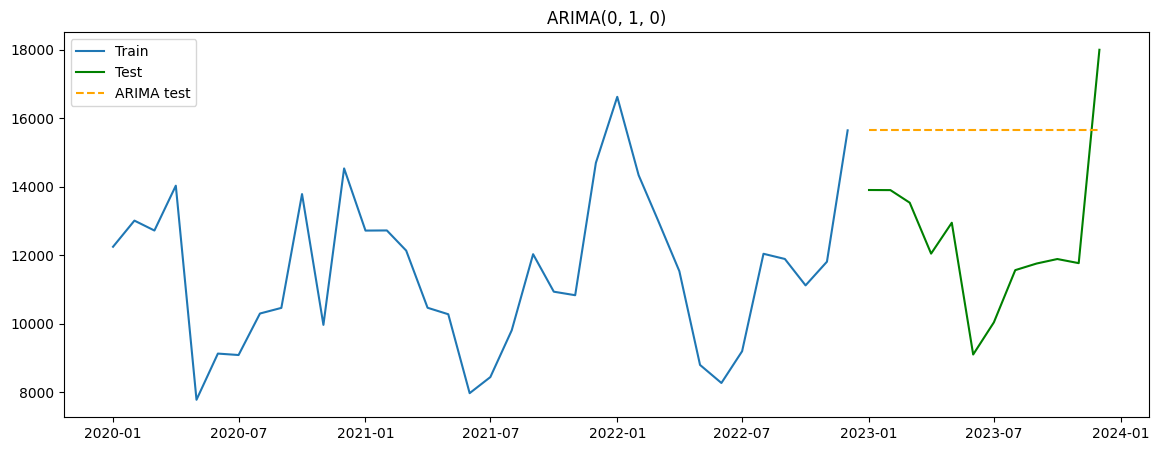

In [16]:
arima_pred = arima_model.forecast(steps=len(test))
arima_pred.index = test.index

plt.figure(figsize=(14,5))
plt.plot(train.index, train['SalesAmount'], label='Train')
plt.plot(test.index, test['SalesAmount'], label='Test', color='green')
plt.plot(test.index, arima_pred, label='ARIMA test', color='orange', linestyle='--')
plt.title(f'ARIMA{best_order}')
plt.legend()
plt.show()

## Модель SARIMAX (с учётом сезонности и экзогенных переменных):

In [17]:
exog_train = train[['Promotion', 'HolidayMonth']]
exog_test = test[['Promotion', 'HolidayMonth']]

Поиск оптимальных параметров для сезонной модели SARIMAX с учётом недельных паттернов (s=12) путём перебора комбинаций несезонных и сезонных порядков:

In [18]:
s = 12

p_range, d_range, q_range = list(range(3)), [1], list(range(3))
P_range, D_range, Q_range = list(range(2)), list(range(2)), list(range(2))
best_aic, best_order_s, best_seasonal = float('inf'), None, None

for p, d, q in product(p_range, d_range, q_range):
    for P, D, Q in product(P_range, D_range, Q_range):
        try:
            model = SARIMAX(train['SalesAmount'], order=(p,d,q), seasonal_order=(P,D,Q,s), exog=exog_train,
                            enforce_stationarity=False, enforce_invertibility=False).fit()
            if model.aic < best_aic:
                best_aic, best_order_s, best_seasonal = model.aic, (p,d,q), (P,D,Q,s)
        except:
            continue

print(f"Лучшая модель SARIMAX по AIC: {best_order_s}x{best_seasonal} с AIC = {best_aic:.2f}")

Лучшая модель SARIMAX по AIC: (2, 1, 2)x(0, 1, 1, 12) с AIC = 133.73


In [19]:
sarimax_model = SARIMAX(train['SalesAmount'], order=best_order_s, seasonal_order=best_seasonal,
                        exog=exog_train, enforce_stationarity=False, enforce_invertibility=False).fit()
sarimax_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                          SalesAmount   No. Observations:                   36
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                 -58.866
Date:                              Mon, 09 Mar 2026   AIC                            133.731
Time:                                      10:17:34   BIC                            134.367
Sample:                                  01-01-2020   HQIC                           129.445
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2583.2959   1926.049      1.341      0.180   -1191.691    6358.283
HolidayMonth     0.7044   3.15e+04   2.24e-05      1.000   -6.17e+04    6.17e+04
ar.L1           -0.3536      1.354     -0.261      0.794      -3.008       2.301
ar.L2           -0.7435      1.200     -0.619      0.536      -3.096       1.609
ma.L1           -1.2918      0.508     -2.544      0.011      -2.287      -0.296
ma.L2            0.4929      0.245      2.011      0.044       0.013       0.973
ma.S.L12        -1.0160      1.982     -0.513      0.608      -4.901       2.869
sigma2        9.406e+04    412.117    228.247      0.000    9.33e+04    9.49e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 1.41
Prob(Q):                              0.72   Prob(JB):                         0.49
Heteroskedasticity (H):               1.13   Skew:                             1.02
Prob(H) (two-sided):                  0.92   Kurtosis:                         3.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.65e+19. Standard errors may be unstable.
"""

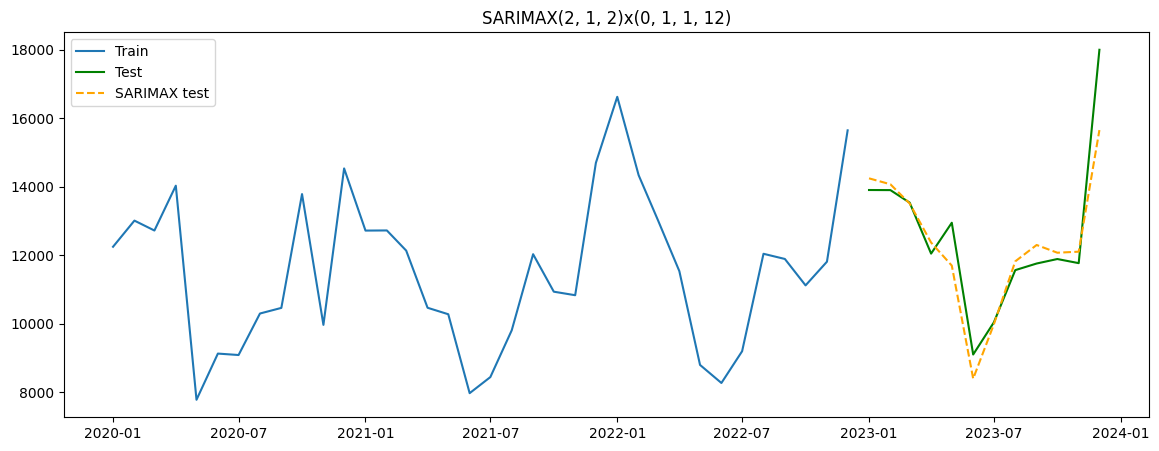

In [20]:
sarimax_pred = sarimax_model.forecast(steps=len(test), exog=exog_test)
sarimax_pred.index = test.index

plt.figure(figsize=(14,5))
plt.plot(train.index, train['SalesAmount'], label='Train')
plt.plot(test.index, test['SalesAmount'], label='Test', color='green')
plt.plot(test.index, sarimax_pred, label='SARIMAX test', color='orange', linestyle='--')
plt.title(f'SARIMAX{best_order_s}x{best_seasonal}')
plt.legend()
plt.show()

Возьмём для SARIMAX параметры ARIMA:

In [21]:
p_range_by_arima, d_range_by_arima, q_range_by_arima = [[item] for item in best_order] # возьмём значения ARIMA
P_range_by_arima, D_range_by_arima, Q_range_by_arima = list(range(2)), list(range(2)), list(range(2))
best_aic_by_arima, best_order_s_by_arima, best_seasonal_by_arima = float('inf'), None, None

for p, d, q in product(p_range_by_arima, d_range_by_arima, q_range_by_arima):
    for P, D, Q in product(P_range_by_arima, D_range_by_arima, Q_range_by_arima):
        try:
            model = SARIMAX(train['SalesAmount'], order=(p,d,q), seasonal_order=(P,D,Q,s), exog=exog_train,
                            enforce_stationarity=False, enforce_invertibility=False).fit()
            if model.aic < best_aic_by_arima:
                best_aic_by_arima, best_order_s_by_arima, best_seasonal_by_arima = model.aic, (p,d,q), (P,D,Q,s)
        except:
            continue

print(f"Лучшая модель SARIMAX с параметрами ARIMA по AIC: {best_order_s_by_arima}x{best_seasonal_by_arima} с AIC = {best_aic_by_arima:.2f}")

Лучшая модель SARIMAX с параметрами ARIMA по AIC: (0, 1, 0)x(0, 1, 1, 12) с AIC = 170.65


In [22]:
sarimax_model_by_arima = SARIMAX(train['SalesAmount'], order=best_order_s_by_arima, seasonal_order=best_seasonal_by_arima,
                                 exog=exog_train, enforce_stationarity=False, enforce_invertibility=False).fit()
sarimax_model_by_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                          SalesAmount   No. Observations:                   36
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                 -81.324
Date:                              Mon, 09 Mar 2026   AIC                            170.649
Time:                                      10:17:37   BIC                            171.859
Sample:                                  01-01-2020   HQIC                           169.321
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     3515.9321   1368.260      2.570      0.010     834.191    6197.673
HolidayMonth    -4.5729   8.61e+04  -5.31e-05      1.000   -1.69e+05    1.69e+05
ma.S.L12        -1.1625      2.830     -0.411      0.681      -6.710       4.385
sigma2         4.08e+05   1.26e+06      0.325      0.746   -2.06e+06    2.87e+06
===================================================================================
Ljung-Box (L1) (Q):                   3.39   Jarque-Bera (JB):                 0.47
Prob(Q):                              0.07   Prob(JB):                         0.79
Heteroskedasticity (H):               0.87   Skew:                             0.52
Prob(H) (two-sided):                  0.91   Kurtosis:                         2.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

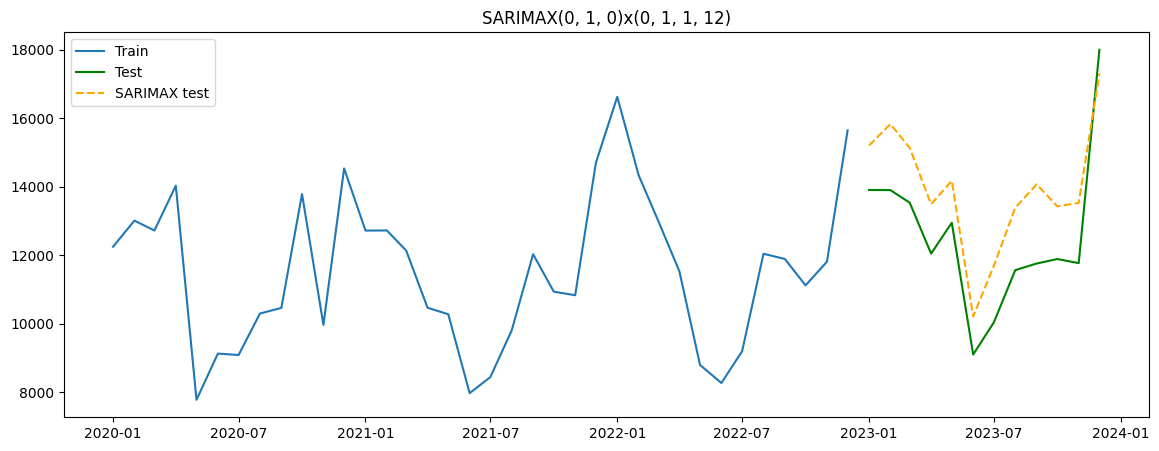

In [23]:
sarimax_pred_by_arima = sarimax_model_by_arima.forecast(steps=len(test), exog=exog_test)
sarimax_pred_by_arima.index = test.index

plt.figure(figsize=(14,5))
plt.plot(train.index, train['SalesAmount'], label='Train')
plt.plot(test.index, test['SalesAmount'], label='Test', color='green')
plt.plot(test.index, sarimax_pred_by_arima, label='SARIMAX test', color='orange', linestyle='--')
plt.title(f'SARIMAX{best_order_s_by_arima}x{best_seasonal_by_arima}')
plt.legend()
plt.show()

## Оценка результатов прогнозирования:

Выполним прогноз на 2024 год (будущие 12 месяцев):

In [24]:
future_period = 12
future_index = pd.date_range(df.index[-1] + pd.offsets.MonthBegin(1), periods=future_period)
future_exog = pd.DataFrame(
    {
        "Promotion": np.zeros(future_period, dtype=int),
        "HolidayMonth": (future_index.month == 12).astype(int),
    },
    index=future_index,
)

arima_full = ARIMA(df["SalesAmount"], order=best_order).fit()
sarimax_full = SARIMAX(df["SalesAmount"], order=best_order_s, seasonal_order=best_seasonal,
                       exog=df[['Promotion', 'HolidayMonth']], enforce_stationarity=False, enforce_invertibility=False).fit()
sarimax_full_by_arima = SARIMAX(df["SalesAmount"], order=best_order_s_by_arima, seasonal_order=best_seasonal_by_arima,
                                exog=df[['Promotion', 'HolidayMonth']], enforce_stationarity=False, enforce_invertibility=False).fit()

arima_future = arima_full.forecast(steps=future_period)
sarimax_future = sarimax_full.forecast(steps=future_period, exog=future_exog)
sarimax_future_by_arima = sarimax_full_by_arima.forecast(steps=future_period, exog=future_exog)

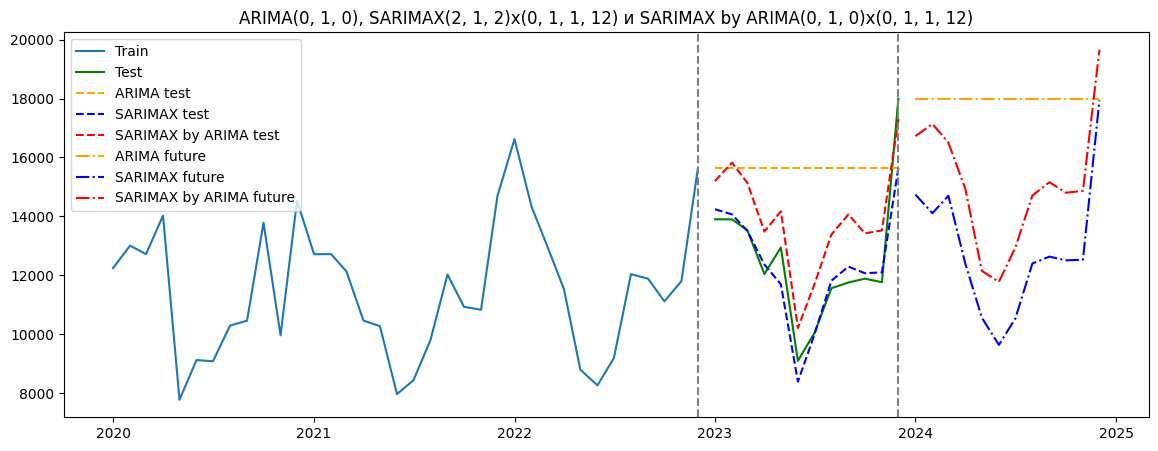

In [25]:
plt.figure(figsize=(14,5))
plt.plot(train.index, train['SalesAmount'], label='Train')
plt.plot(test.index, test['SalesAmount'], label='Test', color='green')
plt.plot(test.index, arima_pred, label='ARIMA test', color='orange', linestyle='--')
plt.plot(test.index, sarimax_pred, label='SARIMAX test', color='blue', linestyle='--')
plt.plot(test.index, sarimax_pred_by_arima, label='SARIMAX by ARIMA test', color='red', linestyle='--')
plt.plot(arima_future.index, arima_future, label='ARIMA future', color='orange', linestyle='-.')
plt.plot(sarimax_future.index, sarimax_future, label='SARIMAX future', color='blue', linestyle='-.')
plt.plot(sarimax_future_by_arima.index, sarimax_future_by_arima, label='SARIMAX by ARIMA future', color='red', linestyle='-.')
plt.axvline(x=train.index[-1], color='grey', linestyle='--')
plt.axvline(x=test.index[-1], color='grey', linestyle='--')
plt.title(f'ARIMA{best_order}, SARIMAX{best_order_s}x{best_seasonal} и SARIMAX by ARIMA{best_order_s_by_arima}x{best_seasonal_by_arima}')
plt.legend()
plt.show()

Параметры ARIMA и SARIMAX подобраны на основе EDA и декомпозиции (d=1, сезонность с периодом 12). SARIMAX учитывает как внутреннюю сезонность ряда,так и внешние факторы (Promotion, HolidayMonth) и, как правило, даёт более точный прогноз

**Выводы**:
- Результаты анализа остатков показывают, что модель SARIMAX описывает данные лучше, чем ARIMA: автокорреляция остатков снизилась, что подтверждается тестом Льюнга–Бокса (p-value > 0.05), однако Q–Q график всё ещё демонстрирует отклонения от нормального распределения на концах распределения. Наличие тяжёлых хвостов может свидетельствовать о влиянии выбросов или о том, что модель не полностью учитывает возможные нелинейные особенности временного ряда.
- Прогноз на 12 месяцев вперёд демонстрирует сохранение исторической сезонной структуры с ожидаемым ростом продаж в декабре, при этом неопределённость прогноза закономерно возрастает с увеличением горизонта прогнозирования.

# 3 | Оценка качества моделей


## Метрики качества прогноза:

In [26]:
quality_metrics = pd.DataFrame([
    {'Model': 'ARIMA', 'MSE': mean_squared_error(test['SalesAmount'], arima_pred), 'R²': r2_score(test['SalesAmount'], arima_pred)},
    {'Model': 'SARIMAX', 'MSE': mean_squared_error(test['SalesAmount'], sarimax_pred), 'R²': r2_score(test['SalesAmount'], sarimax_pred)},
    {'Model': 'SARIMAX by ARIMA', 'MSE': mean_squared_error(test['SalesAmount'], sarimax_pred_by_arima), 'R²': r2_score(test['SalesAmount'], sarimax_pred_by_arima)}
])
quality_metrics

,Model,MSE,R²
0,ARIMA,1.427468e+07,-2.086514
1,SARIMAX,6.923379e+05,0.850301
2,SARIMAX by ARIMA,2.506687e+06,0.457997


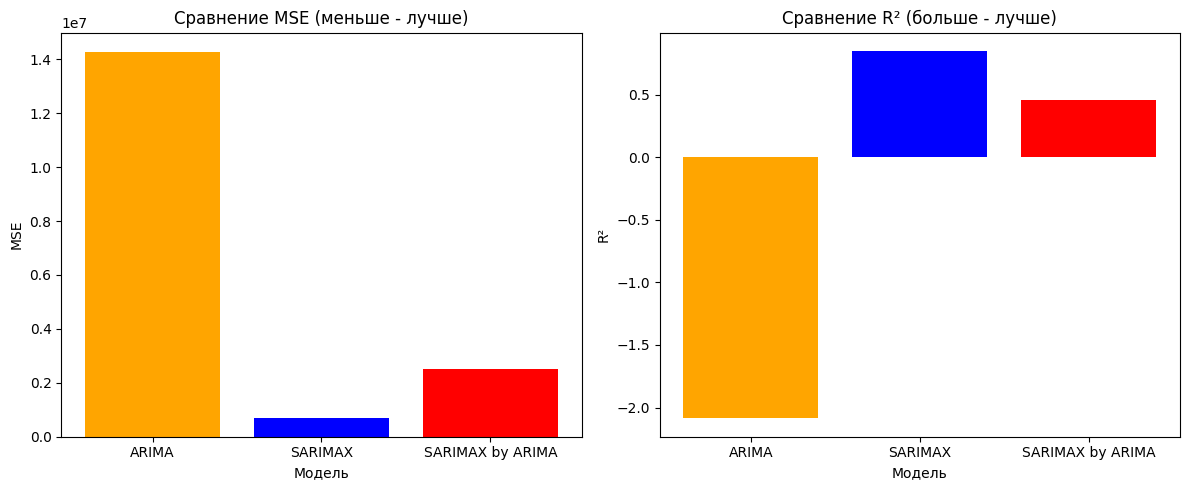

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(quality_metrics['Model'], quality_metrics['MSE'], color=['orange','blue','red'])
axes[0].set_title('Сравнение MSE (меньше - лучше)')
axes[0].set_ylabel('MSE')
axes[0].set_xlabel('Модель')

axes[1].bar(quality_metrics['Model'], quality_metrics['R²'], color=['orange','blue','red'])
axes[1].set_title('Сравнение R² (больше - лучше)')
axes[1].set_ylabel('R²')
axes[1].set_xlabel('Модель')

plt.tight_layout()
plt.show()

## Информационные критерии:

In [28]:
info_metrics = pd.DataFrame([
    {'Model': 'ARIMA', 'AIC': arima_model.aic, 'BIC': arima_model.bic},
    {'Model': 'SARIMAX', 'AIC': sarimax_model.aic, 'BIC': sarimax_model.bic},
    {'Model': 'SARIMAX by ARIMA', 'AIC': sarimax_model_by_arima.aic, 'BIC': sarimax_model_by_arima.bic}
])
info_metrics

,Model,AIC,BIC
0,ARIMA,640.477942,642.033290
1,SARIMAX,133.731265,134.366797
2,SARIMAX by ARIMA,170.648651,171.858991


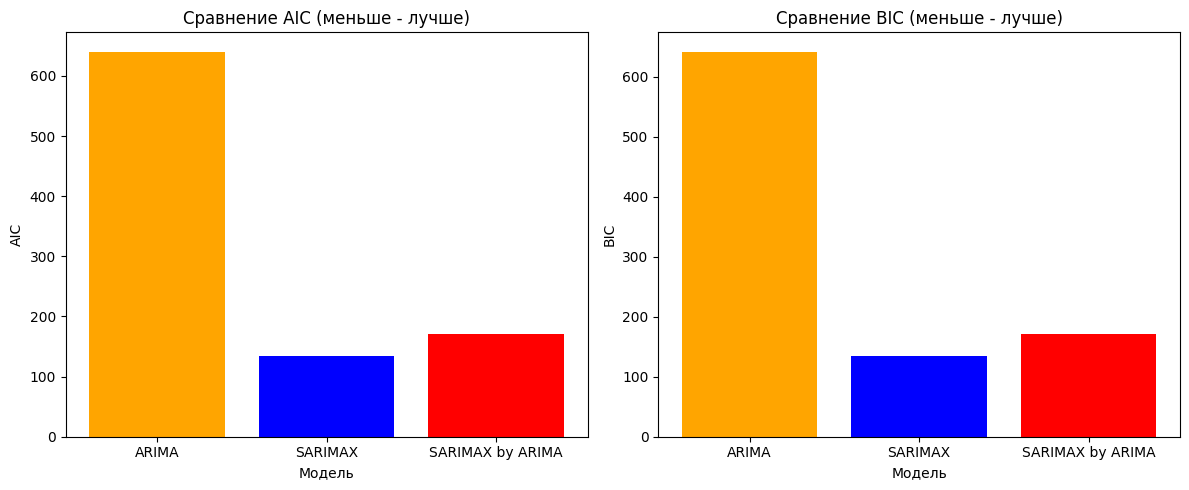

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(info_metrics['Model'], info_metrics['AIC'], color=['orange','blue','red'])
axes[0].set_title('Сравнение AIC (меньше - лучше)')
axes[0].set_ylabel('AIC')
axes[0].set_xlabel('Модель')

axes[1].bar(info_metrics['Model'], info_metrics['BIC'], color=['orange','blue','red'])
axes[1].set_title('Сравнение BIC (меньше - лучше)')
axes[1].set_ylabel('BIC')
axes[1].set_xlabel('Модель')

plt.tight_layout()
plt.show()

## Анализ остатков моделей:


АНАЛИЗ ОСТАТКОВ: ARIMA


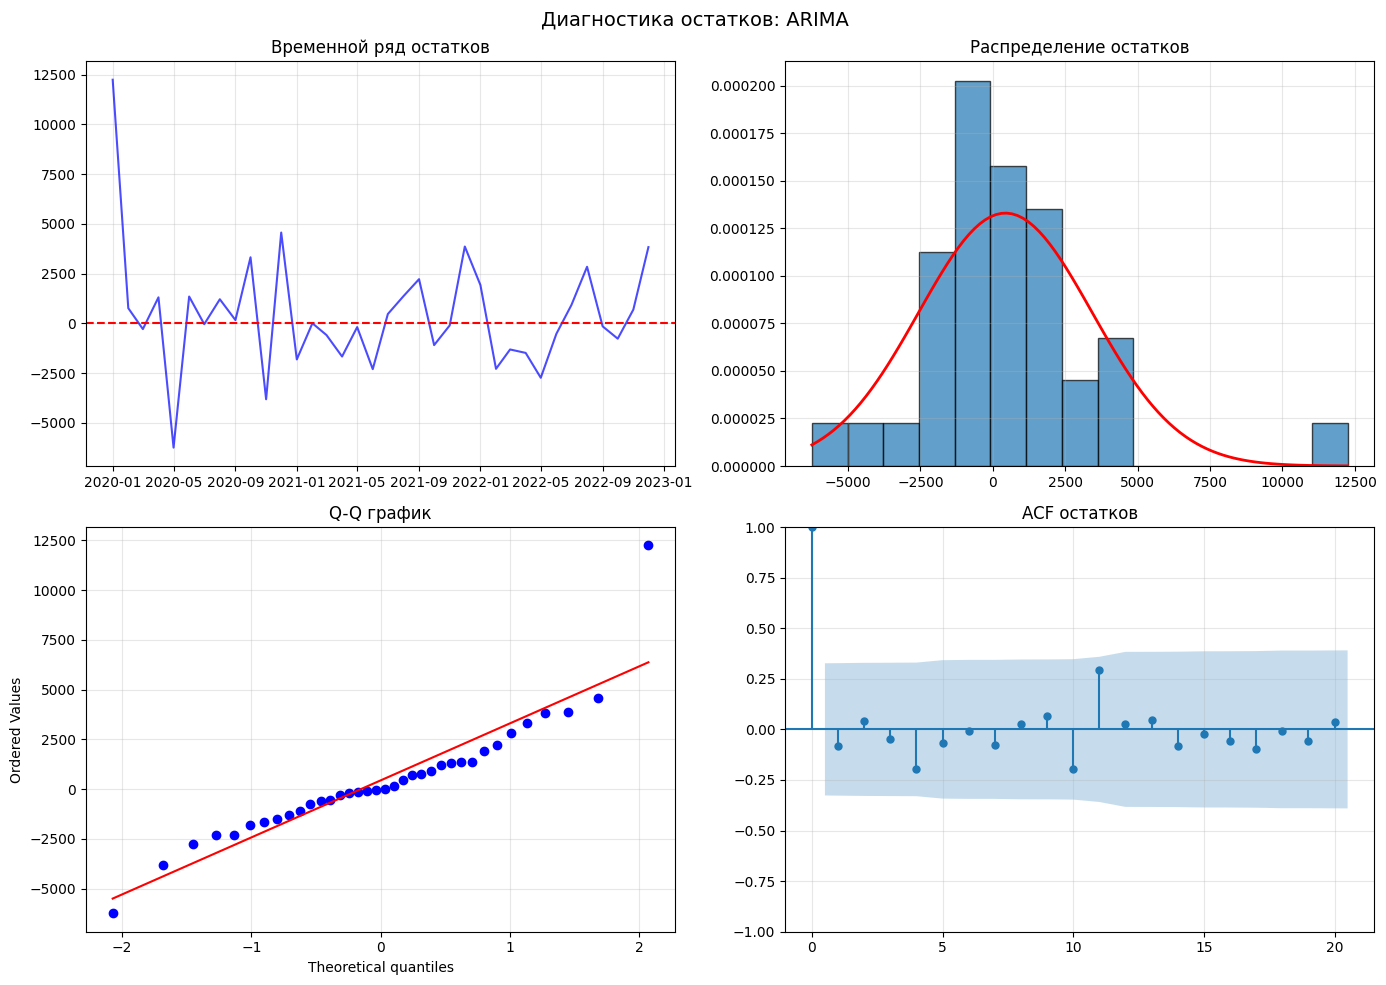

Тест Шапиро-Уилка (нормальность): статистика=0.8805, p=0.0010
  - остатки НЕ распределены нормально
Тест Льюнга-Бокса (автокорреляция): статистика=4.8311, p=0.9022
  - автокорреляция отсутствует
Тест Дарбина-Уотсона: DW=1.6528
  - автокорреляция отсутствует (DW близко к 2)


In [30]:
def check_residuals(residuals, model_name):
    print(f"\n{'='*60}")
    print(f"АНАЛИЗ ОСТАТКОВ: {model_name}")
    print(f"{'='*60}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0,0].plot(residuals, color='blue', linestyle='-', alpha=0.7)
    axes[0,0].axhline(y=0, color='red', linestyle='--')
    axes[0,0].set_title('Временной ряд остатков')
    axes[0,0].grid(True, alpha=0.3)

    axes[0,1].hist(residuals, bins=15, edgecolor='black', alpha=0.7, density=True)
    x_range = np.linspace(residuals.min(), residuals.max(), 100)
    axes[0,1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
                   color='red', linewidth=2)
    axes[0,1].set_title('Распределение остатков')
    axes[0,1].grid(True, alpha=0.3)

    stats.probplot(residuals, dist="norm", plot=axes[1,0])
    axes[1,0].set_title('Q-Q график')
    axes[1,0].grid(True, alpha=0.3)

    plot_acf(residuals, lags=20, ax=axes[1,1], alpha=0.05)
    axes[1,1].set_title('ACF остатков')
    axes[1,1].grid(True, alpha=0.3)

    plt.suptitle(f'Диагностика остатков: {model_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    if len(residuals) <= 5000:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
        print(f"Тест Шапиро-Уилка (нормальность): статистика={shapiro_stat:.4f}, p={shapiro_p:.4f}")
        if shapiro_p > 0.05:
            print("  - остатки распределены нормально")
        else:
            print("  - остатки НЕ распределены нормально")

    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_stat = lb_test['lb_stat'].values[0]
    lb_pvalue = lb_test['lb_pvalue'].values[0]
    print(f"Тест Льюнга-Бокса (автокорреляция): статистика={lb_stat:.4f}, p={lb_pvalue:.4f}")
    if lb_pvalue > 0.05:
        print("  - автокорреляция отсутствует")
    else:
        print("  - автокорреляция присутствует")

    dw_stat = durbin_watson(residuals)
    print(f"Тест Дарбина-Уотсона: DW={dw_stat:.4f}")
    if 1.5 < dw_stat < 2.5:
        print("  - автокорреляция отсутствует (DW близко к 2)")
    else:
        print("  - возможна автокорреляция")

check_residuals(arima_model.resid, 'ARIMA')


АНАЛИЗ ОСТАТКОВ: SARIMAX


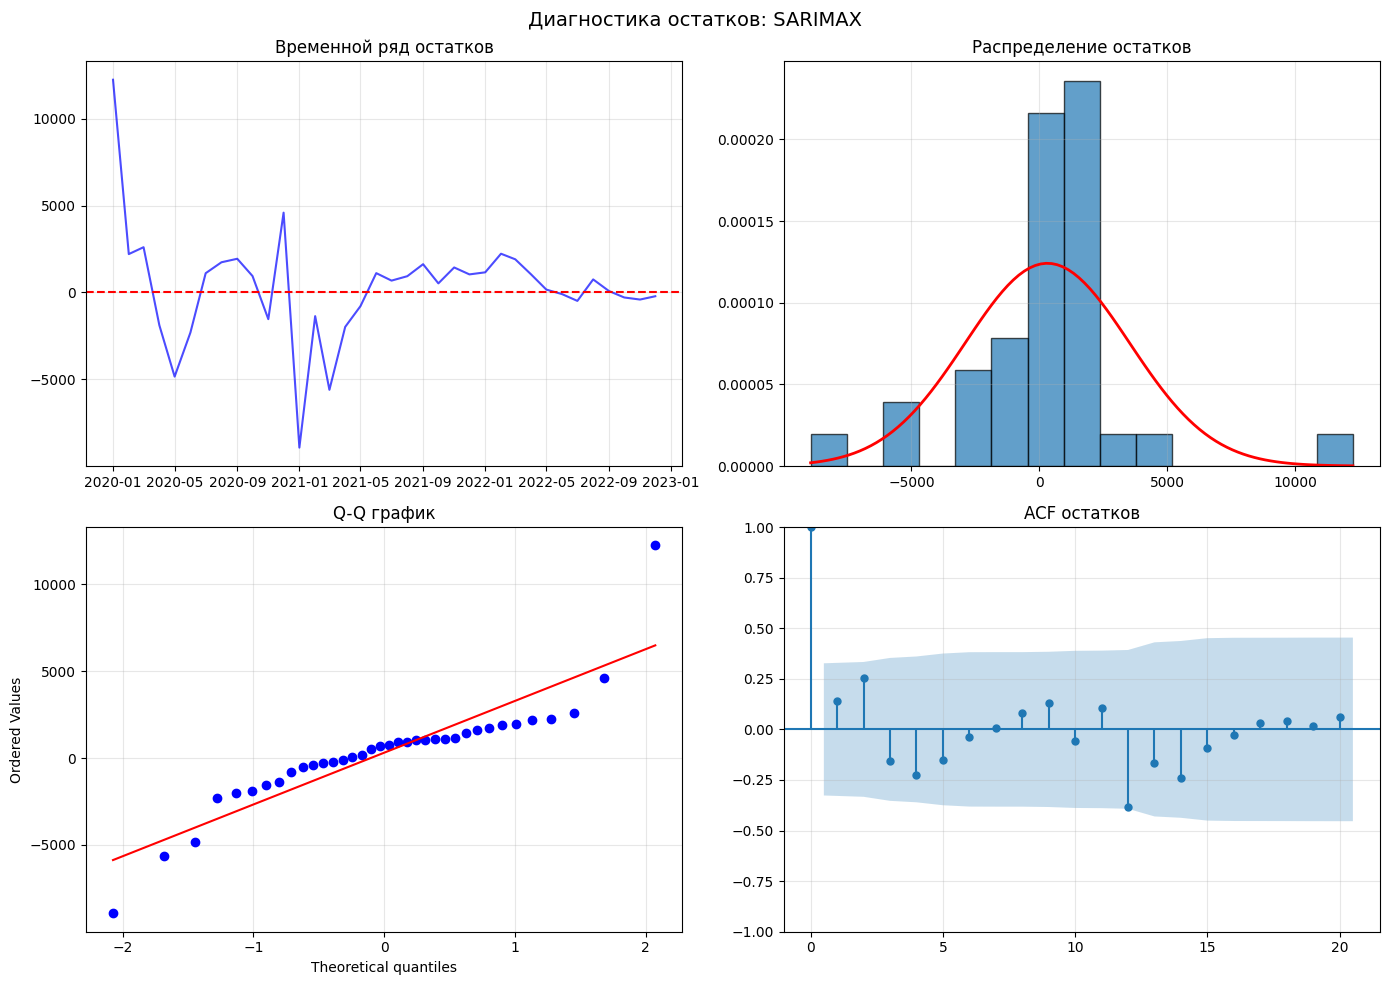

Тест Шапиро-Уилка (нормальность): статистика=0.8388, p=0.0001
  - остатки НЕ распределены нормально
Тест Льюнга-Бокса (автокорреляция): статистика=8.9569, p=0.5362
  - автокорреляция отсутствует
Тест Дарбина-Уотсона: DW=1.3094
  - возможна автокорреляция


In [31]:
check_residuals(sarimax_model.resid, 'SARIMAX')


АНАЛИЗ ОСТАТКОВ: SARIMAX by ARIMA


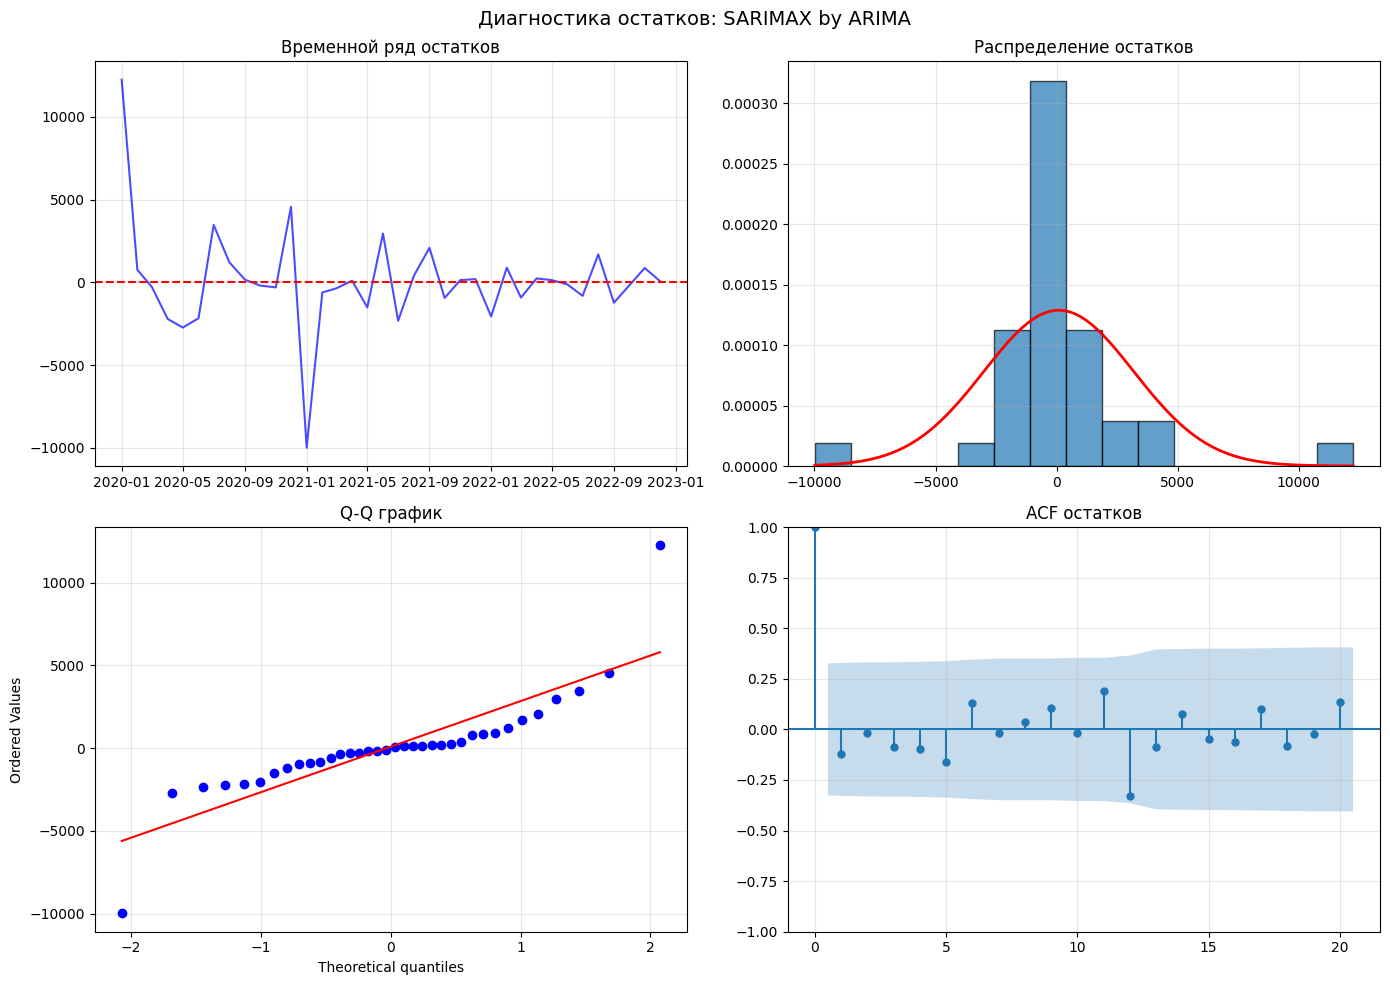

Тест Шапиро-Уилка (нормальность): статистика=0.7790, p=0.0000
  - остатки НЕ распределены нормально
Тест Льюнга-Бокса (автокорреляция): статистика=3.8362, p=0.9544
  - автокорреляция отсутствует
Тест Дарбина-Уотсона: DW=1.8051
  - автокорреляция отсутствует (DW близко к 2)


In [32]:
check_residuals(sarimax_model_by_arima.resid, 'SARIMAX by ARIMA')

**Вывод**: По значениям MSE, R², AIC и BIC предпочтительной является модель SARIMAX (та, для которой выполнялся подбор параметров без учёта ARIMA), которая учитывает сезонную структуру ряда и влияние внешних факторов, что приводит к наилучшим показателям точности прогноза среди рассмотренных вариантов

# Итоговый вывод

В ходе работы был проведён анализ временного ряда розничных продаж, в результате которого была выявлена выраженная годовая сезонность с периодом в 12 месяцев. Для моделирования и прогнозирования были построены модели ARIMA, SARIMAX и SARIMAX на основе параметров ARIMA. Сравнение моделей по метрикам качества показало, что наилучшие результаты демонстрирует модель SARIMAX с подбором параметров, которая учитывает как сезонную структуру временного ряда, так и влияние внешних переменных (Promotion и HolidayMonth). Анализ остатков подтвердил корректность спецификации выбранной модели. Построенный прогноз на 12 месяцев сохраняет характерную сезонную динамику продаж, включая традиционное увеличение объёмов продаж в декабре